# Solar Radio Burst Data Demo

Run the cells below to generate example spectrograms from the synthetic burst generators and view them inline.

In [ ]:
#!pip install matplotlib
#!pip install scipy

In [14]:
from pathlib import Path
import sys

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "data_gen").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not find the repo root containing data_gen")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

from data_gen import (
    generate_no_burst,
    generate_type_1,
    generate_type_2,
    generate_type_3,
    generate_type_4,
    generate_type_5,
    generate_type_6,
    generate_type_7,
    generate_type_8,
    generate_rfi,
)

print(f"Using repo root: {repo_root}")

Using repo root: /Users/prisha/Library/CloudStorage/OneDrive-Personal/Documents/GitHub/solar-radio-classifier


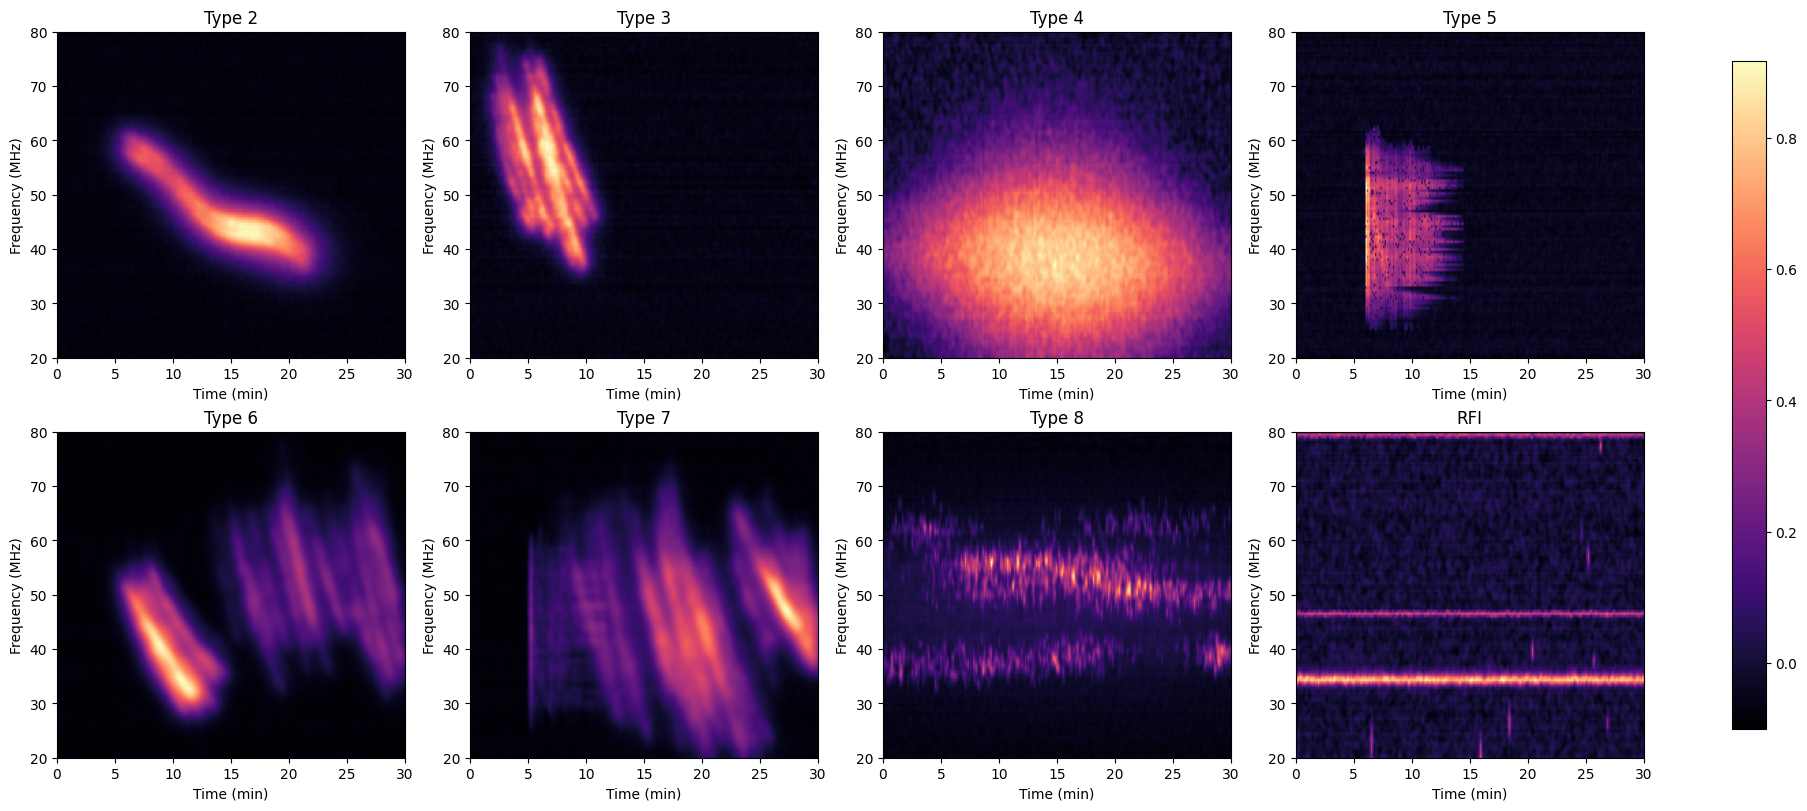

In [15]:
# Physical axis mapping: frequency in MHz, time in minutes
import numpy as np

# Choose physical ranges (adjustable)
f_min_mhz, f_max_mhz = 20.0, 80.0  # MHz
duration_min = 30.0               # total span in minutes
freq_bins = 128
time_bins = 256

# Axis vectors for labeling
freq_axis = np.linspace(f_min_mhz, f_max_mhz, freq_bins)
time_axis = np.linspace(0.0, duration_min, time_bins)

generators = [
    ("Type 2", generate_type_2),
    ("Type 3", generate_type_3),
    ("Type 4", generate_type_4),
    ("Type 5", generate_type_5),
    ("Type 6", generate_type_6),
    ("Type 7", generate_type_7),
    ("Type 8", generate_type_8),
    ("RFI", generate_rfi),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
axes = axes.ravel()

for ax, (title, generator) in zip(axes, generators):
    # Request generator output with the same binning as our axes
    image = generator(freq_bins=freq_bins, time_bins=time_bins)

    # Map array indices to physical units using 'extent' (xmin, xmax, ymin, ymax)
    extent = [time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]]
    im = ax.imshow(image, aspect="auto", origin="lower", cmap="magma", extent=extent)
    ax.set_title(title)
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Frequency (MHz)")
    # show ticks every 5 minutes
    ax.set_xticks(np.linspace(0.0, duration_min, int(duration_min / 5) + 1))

# single colorbar for the grid
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.92)

plt.show()